In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cpu


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f'Training samples: {len(train_dataset)}')
print(f'Test samples: {len(test_dataset)}')
print(f'Image shape: {train_dataset[0][0].shape}')  # [1, 28, 28]


100.0%
100.0%
100.0%
100.0%

Training samples: 60000
Test samples: 10000
Image shape: torch.Size([1, 28, 28])


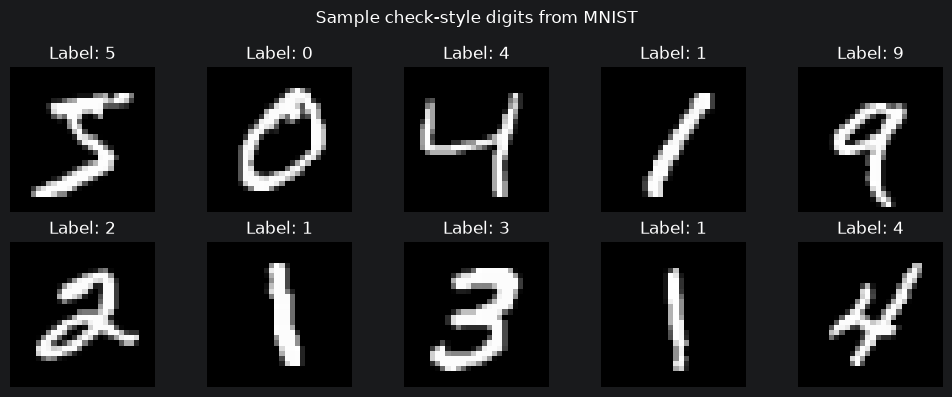

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    img, label = train_dataset[i]
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'Label: {label}')
    ax.axis('off')
plt.suptitle('Sample check-style digits from MNIST')
plt.tight_layout()
plt.show()


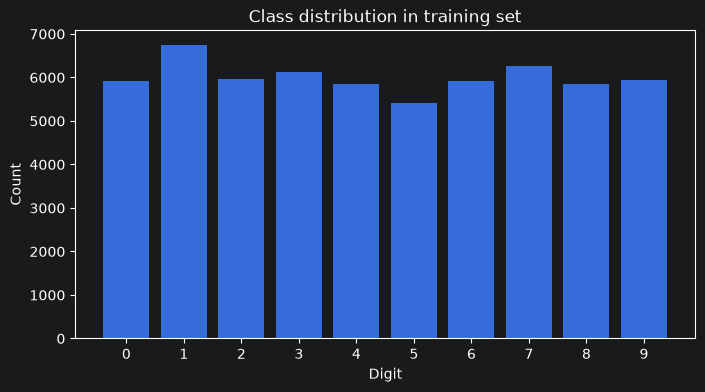

In [9]:
labels = train_dataset.targets.numpy()
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar(unique, counts)
plt.xlabel('Digit')
plt.ylabel('Count')
plt.title('Class distribution in training set')
plt.xticks(range(10))
plt.show()


In [10]:
class DigitMLP(nn.Module):
    def __init__(self, input_size=784, hidden1=256, hidden2=128, num_classes=10):
        super(DigitMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden1)
        self.fc2 = nn.Linear(hidden1, hidden2)
        self.fc3 = nn.Linear(hidden2, num_classes)
        self.relu = nn.ReLU()
        self._initialize_weights()

    def _initialize_weights(self):
        for layer in [self.fc1, self.fc2, self.fc3]:
            nn.init.kaiming_normal_(layer.weight, nonlinearity='relu')
            nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = DigitMLP().to(device)
print(model)


DigitMLP(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
  (relu): ReLU()
)


In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10


In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return running_loss / total, correct / total


Epoch [1/10] - Loss: 0.2095, Accuracy: 93.60%
Epoch [2/10] - Loss: 0.0899, Accuracy: 97.20%
Epoch [3/10] - Loss: 0.0638, Accuracy: 97.92%
Epoch [4/10] - Loss: 0.0506, Accuracy: 98.36%
Epoch [5/10] - Loss: 0.0389, Accuracy: 98.68%
Epoch [6/10] - Loss: 0.0348, Accuracy: 98.86%
Epoch [7/10] - Loss: 0.0309, Accuracy: 98.97%
Epoch [8/10] - Loss: 0.0258, Accuracy: 99.10%
Epoch [9/10] - Loss: 0.0247, Accuracy: 99.17%
Epoch [10/10] - Loss: 0.0243, Accuracy: 99.19%


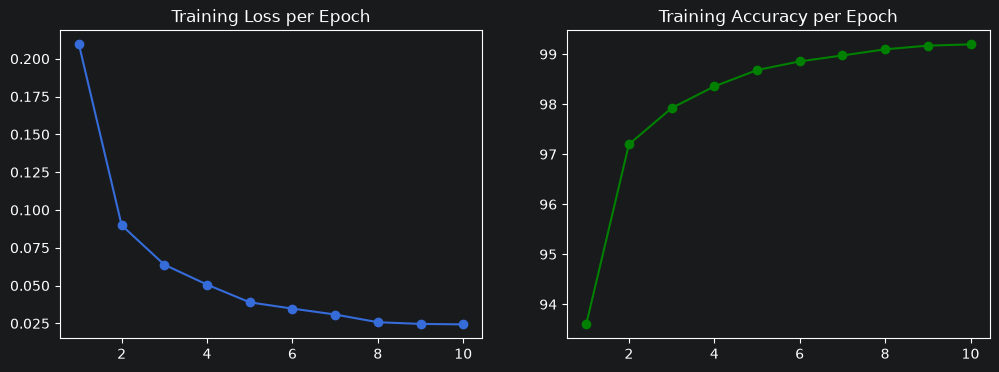

In [13]:
train_losses, train_accs = [], []
for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    print(f'Epoch [{epoch}/{num_epochs}] - Loss: {train_loss:.4f}, Accuracy: {train_acc*100:.2f}%')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, num_epochs + 1), train_losses, marker='o')
axes[0].set_title('Training Loss per Epoch')
axes[1].plot(range(1, num_epochs + 1), [a * 100 for a in train_accs], marker='o', color='green')
axes[1].set_title('Training Accuracy per Epoch')
plt.show()


In [14]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f'Final Test Loss: {test_loss:.4f}')
print(f'Final Test Accuracy: {test_acc*100:.2f}%')


Final Test Loss: 0.1206
Final Test Accuracy: 97.54%


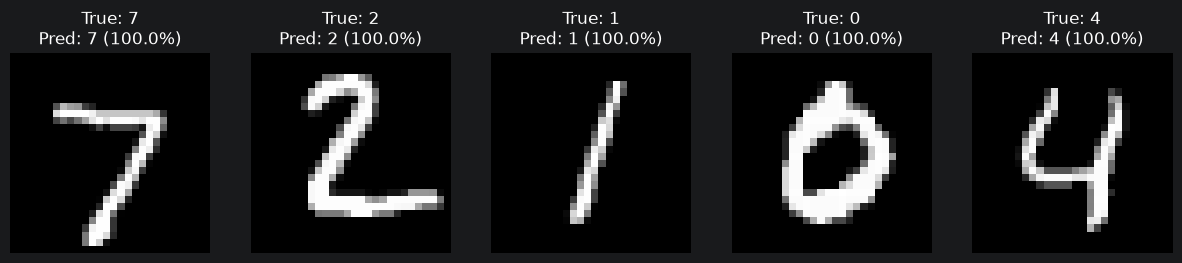

In [15]:
def predict_digit(model, image, device):
    model.eval()
    if image.dim() == 2:
        image = image.unsqueeze(0)
    image = image.unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(image)
        probabilities = F.softmax(logits, dim=1).squeeze(0)
        predicted_label = torch.argmax(probabilities).item()
    return predicted_label, probabilities.cpu().numpy()

sample_indices = [0, 1, 2, 3, 4]
fig, axes = plt.subplots(1, len(sample_indices), figsize=(15, 3))
for ax, idx in zip(axes, sample_indices):
    img, true_label = test_dataset[idx]
    pred_label, probs = predict_digit(model, img, device)
    confidence = probs[pred_label] * 100
    ax.imshow(img.squeeze(), cmap='gray')
    ax.set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)')
    ax.axis('off')
plt.show()
